# How much of the dark-energy evidence is a choice?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/main/examples/05-case-studies/dark_energy_evidence_audit.ipynb)

Two models are widely discussed as evidence that dark energy is not
a cosmological constant:

* **CPL**, $w(a) = w_0 + w_a(1-a)$ — two extra parameters, and the
  model behind DESI's headline result;
* **$\Lambda_{\rm s}$CDM**, in which $\Lambda$ switches sign at a
  redshift $z_\dagger$ — one extra parameter, proposed to relieve
  the $H_0$ tension.

Both are usually quoted against one dataset combination. This
notebook asks what happens to each when the combination changes, by
running the same comparison across a grid of three choices an
analyst makes without much comment:

| axis | options | why it might matter |
|---|---|---|
| **BAO** | none, low-$z$ only, DESI DR1, DESI DR2, eBOSS DR16 | the BAO set is where the headline claims come from |
| **supernovae** | DES-SN5YR, Pantheon+ | two compilations of overlapping data, analysed differently |
| **$r_d$** | computed from $\Omega_b h^2$, or fitted | whether the BAO ruler is calibrated by the CMB or left free |

Twenty combinations, two models, one number each: the $\chi^2$
improvement over $\Lambda$CDM at the best fit.

The question is not "which model is right". It is **which of these
two results would survive an analyst making different reasonable
choices** — and they turn out to fail that audit in completely
different ways.

## What this is and is not

Stated up front, because the whole notebook is one table and it
would be easy to over-read it.

**These are $\Delta\chi^2$ at the best fit, not evidence ratios.**
No priors are integrated, so nothing here is a Bayes factor, and a
model with more parameters is not penalised except by the reader.

**No $\sigma$ is quoted for $\Lambda_{\rm s}$CDM.** Wilks' theorem
needs the null to be interior to the parameter space, and
$\Lambda$CDM sits at $z_\dagger \to \infty$, which is a *boundary*.
The $\chi^2$ distribution there is not $\chi^2_1$, and converting
would overstate the case. CPL's $w_0, w_a$ are interior, so 2-dof
Wilks is fine and is used only there.

**The CMB enters as Planck's compressed distance priors** ($R$,
$\ell_A$, $\omega_b h^2$), not the full likelihood. That is what
makes a 20-cell grid affordable; `s8_tension_cmb.ipynb` does the
full thing for one cosmology.

**The BAO rows are alternatives, not additions.** DESI and eBOSS
cover much of the same sky, so the library refuses to combine them
— each row replaces the others.

**No MCMC.** Every number is a multi-start optimizer result. That
matters more than usual here, and section 2 says why.

In [ ]:
import sys

# On Colab, install the released package. This notebook runs
# twenty fits and is the longest here -- expect the better part
# of an hour on a Colab CPU.

if "google.colab" in sys.modules:
    !pip install -q cosmofit
else:
    print("Not running in Colab -- assuming CosmoFit is already "
          "installed (pip install cosmofit).")


In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from CosmoFit import LCDM, CPL, Fitter, __version__
from CosmoFit.cosmology.models.lscdm import LsCDM
from CosmoFit.stats.model_comparison import (
    likelihood_ratio_test, NESTED_CHI2_TOLERANCE,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

from pathlib import Path

_cwd = Path.cwd()
_base = (
    _cwd / "examples"
    if (_cwd / "examples" / "dark_energy_evidence_audit.ipynb").exists()
    else _cwd
)

FIGURE_DIR = _base / "dark_energy_evidence_audit_figures"
FIGURE_DIR.mkdir(exist_ok=True)


def savefig(fig, name):
    path = FIGURE_DIR / f"{name}.svg"
    fig.savefig(path, bbox_inches="tight")
    print(f"saved {path.name}")


print(f"CosmoFit {__version__}")

CosmoFit 0.28.0


## 1. The grid

Every cell is the same comparison: fit $\Lambda$CDM, fit the
alternative, take the difference of the best-fit $\chi^2$. The
anchors — cosmic chronometers, the supernovae, the Planck distance
priors, and the BBN $\omega_b$ prior — are held fixed; only the
three axes move.

In [2]:
# (extra datasets, dataset_kwargs)
BAO = {
    "none":       ([], None),
    "low-z only": (["bao_lowz"], None),
    "DESI DR1":   (["desi", "bao_lowz"], {"desi": {"version": "desi2024"}}),
    "DESI DR2":   (["desi", "bao_lowz"], {"desi": {"version": "desi2025"}}),
    "eBOSS DR16": (
        ["sdss_bao", "eboss_elg", "eboss_lya", "bao_lowz"], None,
    ),
}

SN = {"DES-SN5YR": "des_sn5yr", "Pantheon+": "pantheon"}

# extra free parameters and their starting values
MODELS = {
    "CPL":   (CPL,   ["w0", "wa"],  {"w0": -0.9, "wa": -0.3}),
    "LsCDM": (LsCDM, ["z_dagger"],  {"z_dagger": 2.5}),
}

BASE = {"H0": 68.0, "Omega_m": 0.315, "Omega_b": 0.0493}

# The DESI version is passed explicitly in every row. `load_desi`
# defaults to DR1, and a first version of this grid silently
# compared DR1 while labelling it DR2 -- the numbers disagreed with
# a separate run, which is the only reason it was caught.

### Why `restarts=`

$\Lambda_{\rm s}$CDM's $\chi^2$ surface has more than one basin.
Where the sign switch crosses the redshift of a BAO measurement the
model's prediction jumps, and a single-start optimizer can converge
cleanly — reporting success — on the wrong side of it.

The check that catches this is free and worth making explicit: a
nested model **cannot** fit worse than the model it contains, so a
negative $\Delta\chi^2$ is never a result, it is a failed fit. Every
cell below asserts it.

In [3]:
def compare(datasets, kwargs, model_cls, extra_free, extra_initial,
            compute_rd, restarts=8, seed=1):
    """LCDM vs one alternative on one dataset combination."""

    free = ["H0", "Omega_m", "Omega_b"] + ([] if compute_rd else ["rd"])
    initial = {**BASE, **({} if compute_rd else {"rd": 147.1})}

    null = Fitter(
        model=LCDM, datasets=datasets, dataset_kwargs=kwargs,
        free_params=free, initial=initial, compute_rd=compute_rd,
    )
    null.best_fit(restarts=restarts, seed=seed)

    alt = Fitter(
        model=model_cls, datasets=datasets, dataset_kwargs=kwargs,
        free_params=free + extra_free,
        initial={**initial, **extra_initial},
        bounds={"z_dagger": (0.5, 100.0)},
        compute_rd=compute_rd,
    )
    alt.best_fit(restarts=restarts, seed=seed)

    delta = null.best_fit_chi2 - alt.best_fit_chi2

    # A nested model cannot fit worse than what it contains.
    assert delta >= -abs(NESTED_CHI2_TOLERANCE), (
        f"delta_chi2 = {delta:.3g}: the optimizer failed, not the model"
    )

    return delta, {k: alt.best_fit_params[k] for k in extra_free}, null.n_data

In [4]:
# ~25 minutes: 20 combinations x 3 fits x 8 restarts, all of them
# analytic likelihoods (no Boltzmann code anywhere in this grid).
t0 = time.time()

rows = []

with warnings.catch_warnings():

    warnings.simplefilter("ignore")

    for sn_label, sn in SN.items():
        for compute_rd in (True, False):
            for bao_label, (bao, kwargs) in BAO.items():

                datasets = ["cc"] + bao + [sn, "planck", "omega_b"]

                entry = {
                    "SN": sn_label,
                    "r_d": "computed" if compute_rd else "fitted",
                    "BAO": bao_label,
                }

                for model_label, (cls, extra, start) in MODELS.items():

                    delta, params, n_data = compare(
                        datasets, kwargs, cls, extra, start, compute_rd,
                    )

                    entry[model_label] = delta
                    entry.update(params)
                    entry["N"] = n_data

                rows.append(entry)

grid = pd.DataFrame(rows)

print(f"{len(grid)} combinations in {time.time() - t0:.0f}s")

20 combinations in 1233s


In [5]:
pd.set_option("display.width", 120)

grid[["SN", "r_d", "BAO", "N", "CPL", "LsCDM", "w0", "wa", "z_dagger"]].round(3)

,SN,r_d,BAO,N,CPL,LsCDM,w0,wa,z_dagger
0,DES-SN5YR,computed,none,1856,3.189,-0.000,-0.813,-0.793,98.083
1,DES-SN5YR,computed,low-z only,1858,2.479,-0.000,-0.850,-0.596,98.083
2,DES-SN5YR,computed,DESI DR1,1870,9.296,3.296,-0.802,-0.793,2.500
3,DES-SN5YR,computed,DESI DR2,1871,11.105,5.400,-0.819,-0.640,2.500
4,DES-SN5YR,computed,eBOSS DR16,1869,5.060,0.299,-0.853,-0.558,4.017
5,DES-SN5YR,fitted,none,1856,3.189,-0.000,-0.813,-0.793,97.008
6,DES-SN5YR,fitted,low-z only,1858,2.828,-0.000,-0.837,-0.665,96.185
7,DES-SN5YR,fitted,DESI DR1,1870,6.074,0.036,-0.822,-0.720,6.704
8,DES-SN5YR,fitted,DESI DR2,1871,8.083,0.809,-0.835,-0.615,3.242
9,DES-SN5YR,fitted,eBOSS DR16,1869,5.129,0.065,-0.834,-0.643,3.760


## 2. $\Lambda_{\rm s}$CDM: fragile in three separate ways

Read down the $\Lambda_{\rm s}$CDM column and it moves by more than
an order of magnitude across choices that are all defensible.

In [6]:
pivot = grid.pivot_table(
    index="BAO", columns=["SN", "r_d"], values="LsCDM",
).reindex(list(BAO))

pivot.round(2)

SN         DES-SN5YR        Pantheon+       
r_d         computed fitted  computed fitted
BAO                                         
none            -0.0  -0.00     -0.00   0.00
low-z only      -0.0  -0.00      0.00   0.00
DESI DR1         3.3   0.04      3.40   0.00
DESI DR2         5.4   0.81      5.32   0.88
eBOSS DR16       0.3   0.07      0.32   0.12

Three separate dependencies, in increasing order of how
uncomfortable they are.

**It needs BAO at all.** With no BAO the improvement is zero to
numerical precision, and $z_\dagger$ runs off to the prior ceiling
— which *is* $\Lambda$CDM. Supernovae plus the CMB have nothing to
say about a sign switch.

**It needs DESI specifically.** Swapping DESI DR2 for eBOSS DR16 —
the previous generation of the same measurement, covering the same
redshifts, including an independent Lyman-$\alpha$ point at
essentially the same $z$ — takes it from 5.40 to 0.30. Section 15
of [`lscdm_mcmc.ipynb`](lscdm_mcmc.ipynb) works through why in
detail.

**And it needs $r_d$ to be computed.** This is the sharpest of the
three, and it is not about the data at all.

## 3. The $r_d$ result

The sound horizon can be handled two ways. Fit it as a free
parameter, and BAO constrains only the product $H_0 r_d$. Compute
it from $\Omega_b h^2$ — which the CMB and BBN pin down — and the
BAO ruler acquires an absolute length, calibrated by physics at
recombination.

The second is the better analysis. It is also where all of
$\Lambda_{\rm s}$CDM's evidence lives.

In [7]:
rd_effect = grid.pivot_table(
    index=["SN", "BAO"], columns="r_d", values=["CPL", "LsCDM"],
).reindex(
    [(sn, bao) for sn in SN for bao in BAO]
)

rd_effect.round(2)

CPL           LsCDM       
r_d                  computed fitted computed fitted
SN        BAO                                       
DES-SN5YR none           3.19   3.19    -0.00  -0.00
          low-z only     2.48   2.83    -0.00  -0.00
          DESI DR1       9.30   6.07     3.30   0.04
          DESI DR2      11.11   8.08     5.40   0.81
          eBOSS DR16     5.06   5.13     0.30   0.07
Pantheon+ none           1.65   1.66    -0.00   0.00
          low-z only     1.15   1.08     0.00   0.00
          DESI DR1       7.15   4.36     3.40   0.00
          DESI DR2       8.96   6.30     5.32   0.88
          eBOSS DR16     3.75   3.64     0.32   0.12

saved rd_treatment.svg


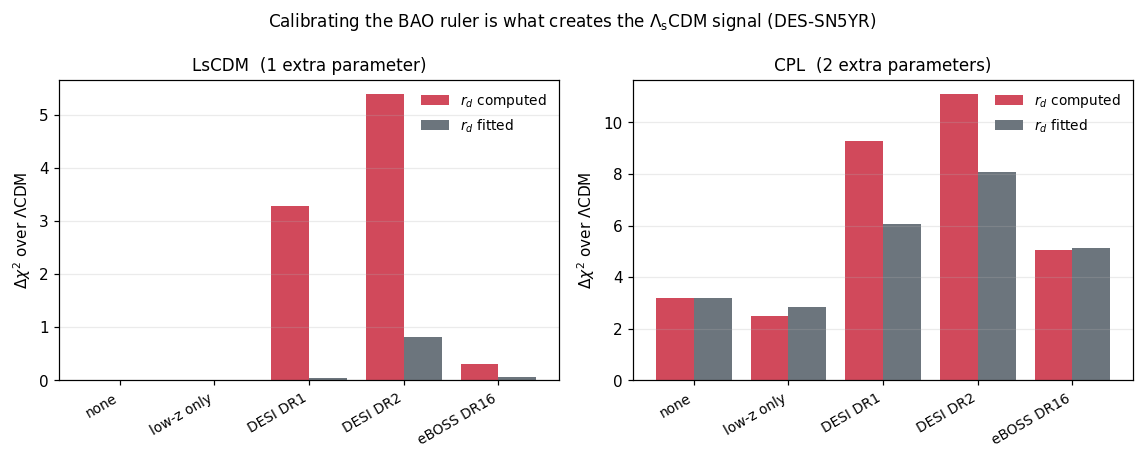

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=False)

for ax, model in zip(axes, ("LsCDM", "CPL")):

    subset = grid[grid["SN"] == "DES-SN5YR"]

    computed = subset[subset["r_d"] == "computed"].set_index("BAO")[model]
    fitted = subset[subset["r_d"] == "fitted"].set_index("BAO")[model]

    order = list(BAO)
    x = np.arange(len(order))

    ax.bar(
        x - 0.2, computed.reindex(order), width=0.4,
        color="#d1495b", label=r"$r_d$ computed",
    )
    ax.bar(
        x + 0.2, fitted.reindex(order), width=0.4,
        color="#6c757d", label=r"$r_d$ fitted",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(r"$\Delta\chi^2$ over $\Lambda$CDM")
    ax.set_title(
        f"{model}  ({len(MODELS[model][1])} extra parameter"
        f"{'s' if len(MODELS[model][1]) > 1 else ''})", fontsize=11,
    )
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False, fontsize=9)

fig.suptitle(
    "Calibrating the BAO ruler is what creates the "
    r"$\Lambda_{\rm s}$CDM signal (DES-SN5YR)", fontsize=11,
)
fig.tight_layout()
savefig(fig, "rd_treatment");

The two panels behave differently, and that difference is the main
result of this notebook.

For $\Lambda_{\rm s}$CDM, fitting $r_d$ instead of computing it
collapses DESI DR2's 5.40 to 0.81 and DR1's 3.30 to 0.04. The
"evidence" is not that the expansion history has a feature; it is
that a *CMB-calibrated* BAO ruler and the CMB's own distance priors
cannot be satisfied at once under $\Lambda$CDM, and a sign switch
relaxes that. Remove the calibration and there is nothing left to
relax.

For CPL the same swap costs some of the improvement and none of the
signal: 11.11 becomes 8.08 with DESI DR2, and with eBOSS it does
not move at all (5.06 against 5.13). CPL is describing something in
the distance-redshift relation itself, which does not care how the
ruler was calibrated.

## 4. CPL: modest everywhere, absent nowhere

The CPL column never reaches DESI DR2's 11.11 anywhere else, and
never falls to zero anywhere either.

In [9]:
cpl = grid.pivot_table(
    index="BAO", columns=["SN", "r_d"], values="CPL",
).reindex(list(BAO))

cpl.round(2)

SN         DES-SN5YR        Pantheon+       
r_d         computed fitted  computed fitted
BAO                                         
none            3.19   3.19      1.65   1.66
low-z only      2.48   2.83      1.15   1.08
DESI DR1        9.30   6.07      7.15   4.36
DESI DR2       11.11   8.08      8.96   6.30
eBOSS DR16      5.06   5.13      3.75   3.64

In [10]:
# Wilks is legitimate here: w0 = -1, wa = 0 is an interior point.
significance = []

for _, row in grid.iterrows():
    result = likelihood_ratio_test(
        chi2_null=0.0, k_null=3,
        chi2_alt=-row["CPL"], k_alt=5,
    )
    significance.append(result["sigma"])

grid["CPL sigma"] = significance

grid.pivot_table(
    index="BAO", columns=["SN", "r_d"], values="CPL sigma",
).reindex(list(BAO)).round(2)

SN         DES-SN5YR        Pantheon+       
r_d         computed fitted  computed fitted
BAO                                         
none            0.83   0.83      0.16   0.16
low-z only      0.55   0.70      0.00   0.00
DESI DR1        2.34   1.66      1.91   1.21
DESI DR2        2.66   2.11      2.28   1.72
eBOSS DR16      1.41   1.43      1.02   0.99

Nothing here reaches $3\sigma$. The strongest cell — DES-SN5YR,
computed $r_d$, DESI DR2 — is $2.66\sigma$, and the weakest cells
read $0.00$. That floor is an artefact worth naming: a
$\Delta\chi^2$ of 1.08 on two degrees of freedom gives $p = 0.58$,
whose one-sided $\sigma$ is *negative*, and
`likelihood_ratio_test` clamps at zero rather than reporting a
negative significance. Read $0.00$ as "no preference", not as
"exactly the null".

$2.66\sigma$ is lower than the numbers usually quoted for DESI's
result, and the reason is in the caveats: this uses Planck's three
compressed distance priors rather than the full CMB likelihood,
which throws away most of the CMB's constraining power. The grid is
built to compare cells against each other, not against the
literature.

What the grid can say, which a single number cannot, is that the
improvement is **present in every configuration**: with no BAO at
all ($+3.19$ from supernovae and the CMB alone), with the low-$z$
BAO that predates both surveys, with either DESI release, and with
eBOSS.

## 5. Where the models actually sit

A $\Delta\chi^2$ says how much better a model fits. It does not say
whether the different configurations agree about *what* the model
should be — and they can easily not, which is what a fragile result
looks like from the inside.

saved parameter_stability.svg


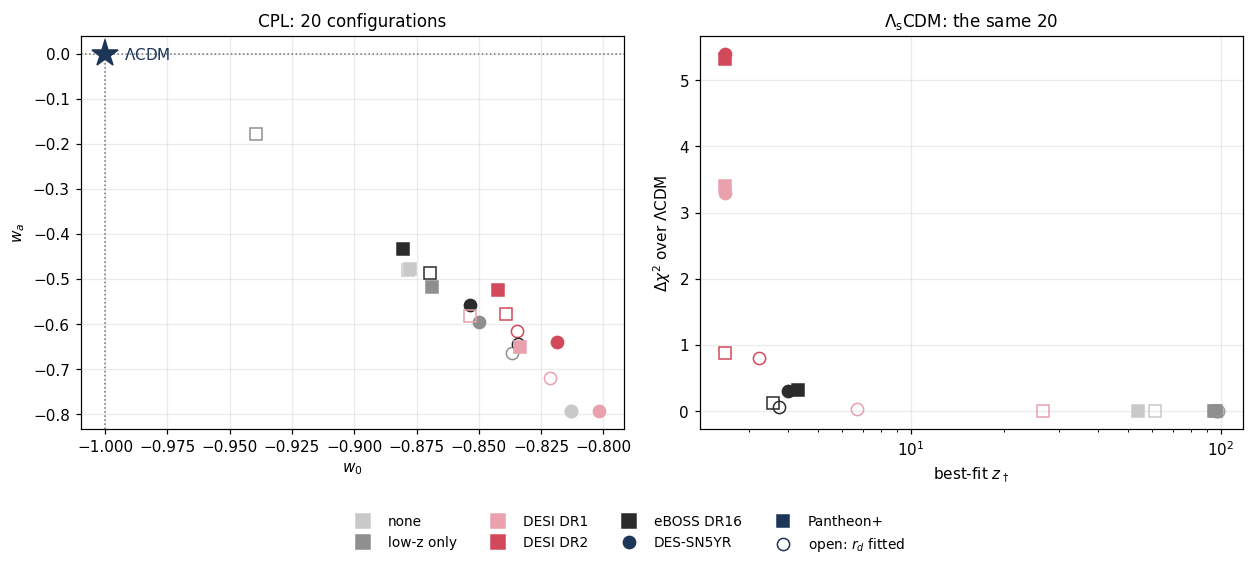

In [11]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

# Three encodings, so all three need a key: colour is the BAO set,
# shape is the supernova compilation, and a hollow marker means r_d
# was fitted rather than computed.
markers = {"DES-SN5YR": "o", "Pantheon+": "s"}
colors = {
    "none": "#c9c9c9", "low-z only": "#8f8f8f",
    "DESI DR1": "#e8a1ad", "DESI DR2": "#d1495b", "eBOSS DR16": "#2b2b2b",
}

for _, row in grid.iterrows():
    axes[0].plot(
        row["w0"], row["wa"], markers[row["SN"]], ms=8,
        color=colors[row["BAO"]],
        mfc="none" if row["r_d"] == "fitted" else colors[row["BAO"]],
    )

axes[0].axvline(-1.0, color="#6c757d", ls=":", lw=1.0)
axes[0].axhline(0.0, color="#6c757d", ls=":", lw=1.0)
axes[0].plot(-1.0, 0.0, "*", ms=18, color="#1d3557", zorder=5)
axes[0].annotate(
    r"$\Lambda$CDM", (-1.0, 0.0), textcoords="offset points",
    xytext=(12, -4), fontsize=10, color="#1d3557",
)
axes[0].set_xlabel(r"$w_0$")
axes[0].set_ylabel(r"$w_a$")
axes[0].set_title("CPL: 20 configurations", fontsize=11)
axes[0].grid(alpha=0.25)

for _, row in grid.iterrows():
    axes[1].plot(
        row["z_dagger"], row["LsCDM"], markers[row["SN"]], ms=8,
        color=colors[row["BAO"]],
        mfc="none" if row["r_d"] == "fitted" else colors[row["BAO"]],
    )
axes[1].set_xscale("log")
axes[1].set_xlabel(r"best-fit $z_\dagger$")
axes[1].set_ylabel(r"$\Delta\chi^2$ over $\Lambda$CDM")
axes[1].set_title(
    r"$\Lambda_{\rm s}$CDM: the same 20", fontsize=11,
)
axes[1].grid(alpha=0.25)

# One key for both panels, outside them, since the encodings are
# shared and a legend inside the left panel reads as a data point.
key = (
    [Line2D([], [], ls="none", marker="s", ms=9, color=c, label=b)
     for b, c in colors.items()]
    + [Line2D([], [], ls="none", marker=m, ms=8, color="#1d3557", label=s)
       for s, m in markers.items()]
    + [Line2D([], [], ls="none", marker="o", ms=8, color="#1d3557",
              mfc="none", label=r"open: $r_d$ fitted")]
)

fig.legend(
    handles=key, loc="lower center", ncol=4, frameon=False,
    fontsize=9, bbox_to_anchor=(0.5, -0.13),
)

fig.tight_layout()
savefig(fig, "parameter_stability");

In [12]:
print("CPL, across all 20 configurations:")
print(f"  w0 in [{grid['w0'].min():.2f}, {grid['w0'].max():.2f}]"
      f"   wa in [{grid['wa'].min():+.2f}, {grid['wa'].max():+.2f}]")
print(f"  all 20 have w0 > -1 and wa < 0: "
      f"{bool((grid['w0'] > -1).all() and (grid['wa'] < 0).all())}")

print("\nLsCDM, across all 20:")
print(f"  z_dagger in [{grid['z_dagger'].min():.2f}, "
      f"{grid['z_dagger'].max():.2f}]")
print(f"  configurations parked at the prior ceiling (z_dagger > 50, "
      f"i.e. LCDM): {(grid['z_dagger'] > 50).sum()} of {len(grid)}")

CPL, across all 20 configurations:
  w0 in [-0.94, -0.80]   wa in [-0.79, -0.18]
  all 20 have w0 > -1 and wa < 0: True
LsCDM, across all 20:
  z_dagger in [2.50, 98.08]
  configurations parked at the prior ceiling (z_dagger > 50, i.e. LCDM): 8 of 20


The left panel is the case for CPL. Every one of the twenty
configurations lands in the same quadrant — $w_0 > -1$ and
$w_a < 0$, dark energy weakening with time — and they cluster
tightly regardless of which supernova compilation, which BAO, or
whether the ruler was calibrated. Configurations that disagree
about how *much* they improve on $\Lambda$CDM agree about what to
replace it with.

The right panel is the case against reading $\Lambda_{\rm s}$CDM
the same way. **Eight of the twenty** put $z_\dagger$ at the prior
ceiling, which is $\Lambda$CDM with an extra parameter along for
the ride. Of the twelve that find something finite, five sit at
$z_\dagger = 2.50$ — every one of them a DESI row, four of the five
with $r_d$ computed — five more spread over $3.2$–$4.3$, and two
wander off to $6.7$ and $26.6$. The $\Delta\chi^2$ tracks which of those groups a
configuration landed in rather than varying smoothly, which is what
a parameter with no stable preferred value looks like.

## Summary

Twenty configurations, two models, one comparison each.

**$\Lambda_{\rm s}$CDM's evidence is a compound of three choices.**
It needs BAO ($0.00$ without), it needs DESI's BAO in particular
($0.30$ with eBOSS DR16), and it needs the sound horizon computed
rather than fitted ($5.40 \to 0.81$). Change any one of the three
and the improvement is gone — and eight of the twenty cells cannot
find a finite $z_\dagger$ at all.

**CPL's evidence is modest but does not depend on any one choice.**
It is present with no BAO at all, with every BAO set, under both
supernova compilations, and under either $r_d$ treatment. It never
reaches $3\sigma$ in this setup — the compressed CMB priors see to
that — but all twenty configurations agree on $w_0 > -1$, $w_a < 0$.

**Neither result is a detection of anything here**, and this
notebook is not the place that would establish one: no MCMC, no
Bayesian evidence, no full CMB likelihood. What a grid *can* do is
distinguish a result that is stable under an analyst's discretion
from one that is a description of a particular set of choices, and
on that test the two models come out very differently.

### Reproducing this

About 25 minutes, no optional dependencies — every likelihood in
the grid is analytic. Figures are written to
`dark_energy_evidence_audit_figures/`.

### See also

* [`lscdm_mcmc.ipynb`](lscdm_mcmc.ipynb) — the full
  $\Lambda_{\rm s}$CDM fit with MCMC and profile likelihoods, and
  section 15 on the DESI dependence in detail.
* [`s8_tension_cmb.ipynb`](s8_tension_cmb.ipynb) — the full Planck
  likelihood rather than the compressed priors used here.
* [REFERENCES.md](../REFERENCES.md) — every dataset in the grid.